In [4]:
from domain.dataset.ohlcv.repository import read_df_aapl
from domain.feature.closes.derive import derive_closes_n4

ohlcv_aapl = read_df_aapl()
closes_n4 = derive_closes_n4(ohlcv_aapl)
closes_n4.df

Date,now,lag_1,lag_2,lag_3,lag_4
datetime[μs],f64,f64,f64,f64,f64
2015-03-05 00:00:00,-167.095474,-63.590753,20.893798,48.922637,-151.025682
2015-03-06 00:00:00,15.019172,-167.095474,-63.590753,20.893798,48.922637
2015-03-09 00:00:00,42.563318,15.019172,-167.095474,-63.590753,20.893798
2015-03-10 00:00:00,-209.028075,42.563318,15.019172,-167.095474,-63.590753
2015-03-11 00:00:00,-183.997085,-209.028075,42.563318,15.019172,-167.095474
…,…,…,…,…,…
2025-02-19 00:00:00,16.348555,-5.316213,126.305343,194.822215,181.052465
2025-02-20 00:00:00,39.127827,16.348555,-5.316213,126.305343,194.822215
2025-02-21 00:00:00,-11.396476,39.127827,16.348555,-5.316213,126.305343


In [5]:
import lightgbm as lgb
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 特徴量とターゲットの分割（to_pandas()で変換）
X = closes_n4.df[['lag_1', 'lag_2', 'lag_3', 'lag_4']].to_pandas()
y = closes_n4.df['now'].to_numpy()  # numpy配列に変換

# 時系列を考慮したデータ分割
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False, random_state=42
)

# LightGBM用データセット作成（labelをnumpy配列で指定）
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# 回帰用パラメータ設定
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.1,
    'num_leaves': 63,
    'verbose': -1
}

# モデル訓練
model = lgb.train(
    params,
    train_data,
    valid_sets=[test_data],
    num_boost_round=500,
    callbacks=[lgb.early_stopping(50)]
)

# 予測と評価
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Test RMSE: {rmse:.4f}')

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 136.075
Test RMSE: 136.0749


In [6]:
print(y_pred)
print(y_pred.shape)

[ -0.97487564  -5.67314335  16.71871531   6.70594813  -5.67314335
   4.57835728  10.20952846  -9.12669023   9.83329732   5.08416409
  21.03182011  -5.67314335   5.43278169  -6.67145572   6.32535205
   6.61850589   3.60737853   7.51411355   3.60737853  -0.53742973
   5.08416409   3.78592922  -5.67314335   1.27906944  16.94244248
  -6.67145572   7.51411355   3.60737853   6.61850589   1.27906944
   4.57835728   3.78592922  10.56464476  22.02209009  10.20952846
   8.971085     9.83329732  10.61298254   6.81587046   6.81587046
  10.84919865   4.57835728  10.03543499   2.40258253   3.78592922
  -9.12669023   9.83329732  17.46452427  10.84919865   4.57835728
  10.20952846   8.971085    16.83332762  10.61298254   3.78592922
  16.83332762  10.84919865  13.20309321  -0.97487564   9.46986745
   6.81587046  -0.53742973  -1.28888474   4.57835728   6.70594813
  -9.12669023   6.81587046   6.61850589   9.83439495   3.60737853
  -0.53742973   4.77111361  13.20309321  -6.67145572   3.78592922
  15.30634

MAE: 100.47
R2 Score: -0.00


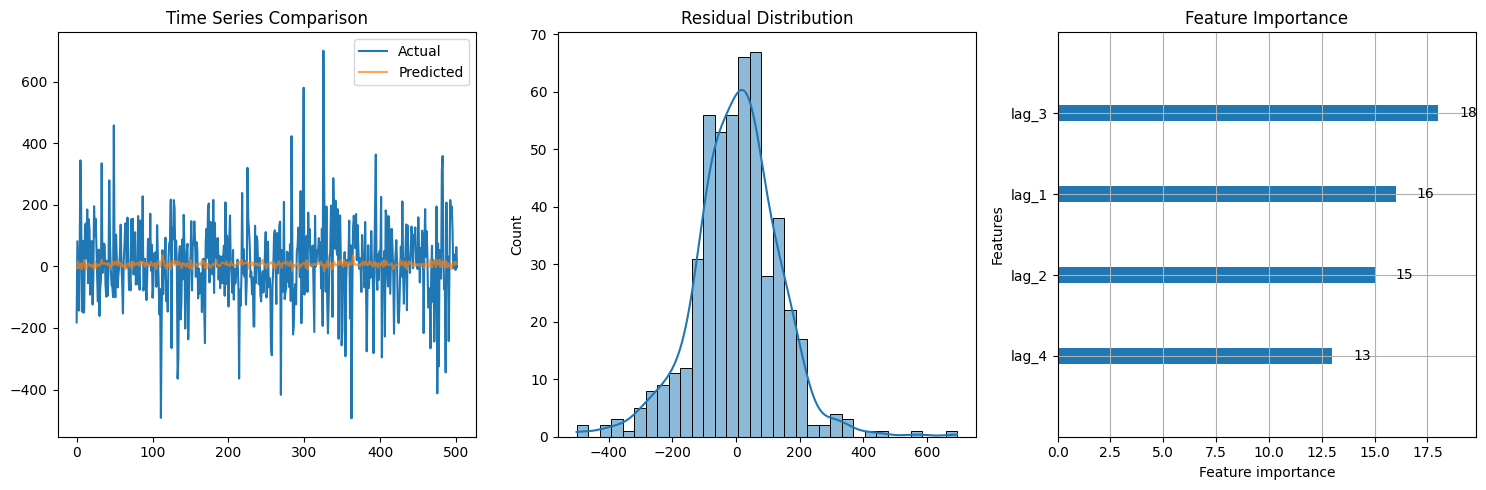

In [7]:
# 追加の評価指標
from sklearn.metrics import mean_absolute_error, r2_score

print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'R2 Score: {r2_score(y_test, y_pred):.2f}')

# 可視化
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# 1. 実際値 vs 予測値の時系列プロット
plt.subplot(1, 3, 1)
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted', alpha=0.7)
plt.title('Time Series Comparison')
plt.legend()

# 2. 残差プロット
plt.subplot(1, 3, 2)
sns.histplot(y_test - y_pred, kde=True)
plt.title('Residual Distribution')

# 3. 特徴量重要度
plt.subplot(1, 3, 3)
lgb.plot_importance(model, max_num_features=10, ax=plt.gca())
plt.title('Feature Importance')

plt.tight_layout()
plt.show()